# Support Vector Machines 
## Oefening
## Fraude bij wijn

Wijnfraude heeft betrekking op de commerciële aspecten van wijn. Het meest voorkomende type fraude is waarbij wijnen worden vervalst, meestal met de toevoeging van goedkopere producten (bijv. sappen) en soms met schadelijke chemicaliën en zoetstoffen (ter compensatie van kleur of smaak).

Namaak en het heretiketteren van inferieure en goedkopere wijnen naar duurdere merken is een ander veelvoorkomend type wijnfraude.

## Doel van het project

Een distributiebedrijf dat onlangs slachtoffer was van fraude heeft een audit voltooid van verschillende wijnmonsters door middel van chemische analyse op monsters. Het distributiebedrijf is gespecialiseerd in het exporteren van extreem hoge kwaliteit, dure wijnen, maar werd bedrogen door een leverancier die probeerde goedkope, lage kwaliteit wijn door te laten gaan als wijn van hogere kwaliteit. Het distributiebedrijf heeft u ingehuurd om te proberen een machine learning model te creëren dat kan helpen bij het detecteren van monsters van lage kwaliteit (ook bekend als "fraude") wijn. Ze willen weten of het zelfs mogelijk is om een dergelijk verschil te detecteren.


Gegevensbron: *P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553, 2009.*

---
---

**TAAK: Je algemene doel is om de hieronder getoonde wijndataset te gebruiken om een machine learning model te ontwikkelen dat probeert te voorspellen of een wijn "Legitiem" of "Fraude" is op basis van verschillende chemische eigenschappen. Voltooi de onderstaande taken om het project te volgen.**

---
---

## Voer de vetgedrukte taken uit

**TAAK: Voer de cellen hieronder uit om de bibliotheken te importeren en de dataset te laden.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/wine_fraud.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


**TAAK: Wat zijn de unieke variabelen in de doelkolom die we proberen te voorspellen (quality)?**

In [4]:
df.quality.value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

**TAAK: Maak een countplot die het aantal per categorie van Legitiem versus Fraude weergeeft. Is het label/doel gebalanceerd of ongebalanceerd?**

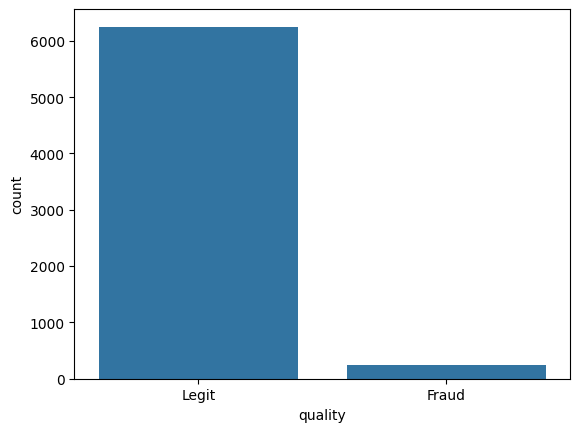

In [6]:
sns.countplot(data=df, x=df.quality);

**TAAK: Onderzoek of er een verschil is tussen rode en witte wijn wat betreft fraude. Maak een countplot met het wijntype op de x-as en een kleur die kolommen scheidt op basis van Fraude versus Legitiem.**

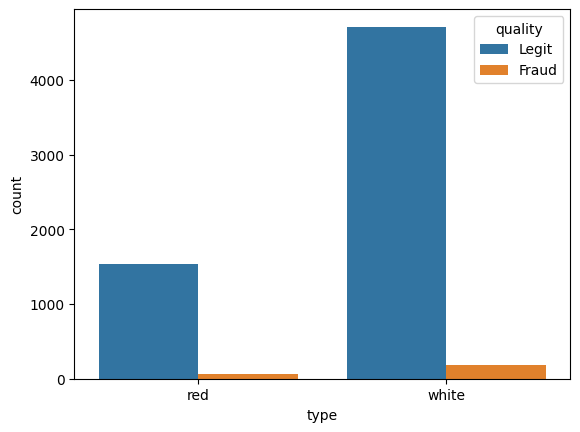

In [8]:
sns.countplot(data=df, x='type', hue='quality');

**TAAK: Welk percentage van de rode wijnen zijn frauduleus? Welk percentage van de witte wijnen zijn frauduleus?**

In [24]:
percentages_per_type = 100 * df.groupby("type")["quality"].value_counts(normalize=True)
print("Frauduleus gedeeltij:")
print(f"- bij rode wijnen: {percentages_per_type.red.Fraud:.2f}%")
print(f"- bij witte wijnen: {percentages_per_type.white.Fraud:.2f}%")

Frauduleus gedeeltij:
- bij rode wijnen: 3.94%
- bij witte wijnen: 3.74%


**TAAK: Bereken de correlatie tussen de verschillende kenmerken en de "kwaliteit"-kolom. Hiervoor moet je mogelijk de kolom naar 0 en 1 mappen in plaats van een string.**

In [25]:
df['Fraud']= df['quality'].map({'Legit':0,'Fraud':1})
wijn_corr=df.corr(numeric_only=True)['Fraud']
wijn_corr

fixed acidity           0.021794
volatile acidity        0.151228
citric acid            -0.061789
residual sugar         -0.048756
chlorides               0.034499
free sulfur dioxide    -0.085204
total sulfur dioxide   -0.035252
density                 0.016351
pH                      0.020107
sulphates              -0.034046
alcohol                -0.051141
Fraud                   1.000000
Name: Fraud, dtype: float64

**TAAK: Maak een staafdiagram van de correlatiewaarden voor frauduleuze wijn.**

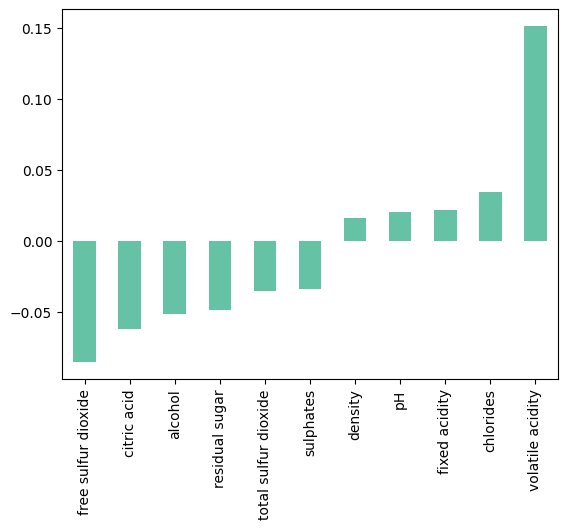

In [29]:
wijn_corr[:-1].sort_values().plot(kind='bar', colormap="Set2");

**TAAK: Maak een clustermap met seaborn om de relaties tussen variabelen te verkennen.**

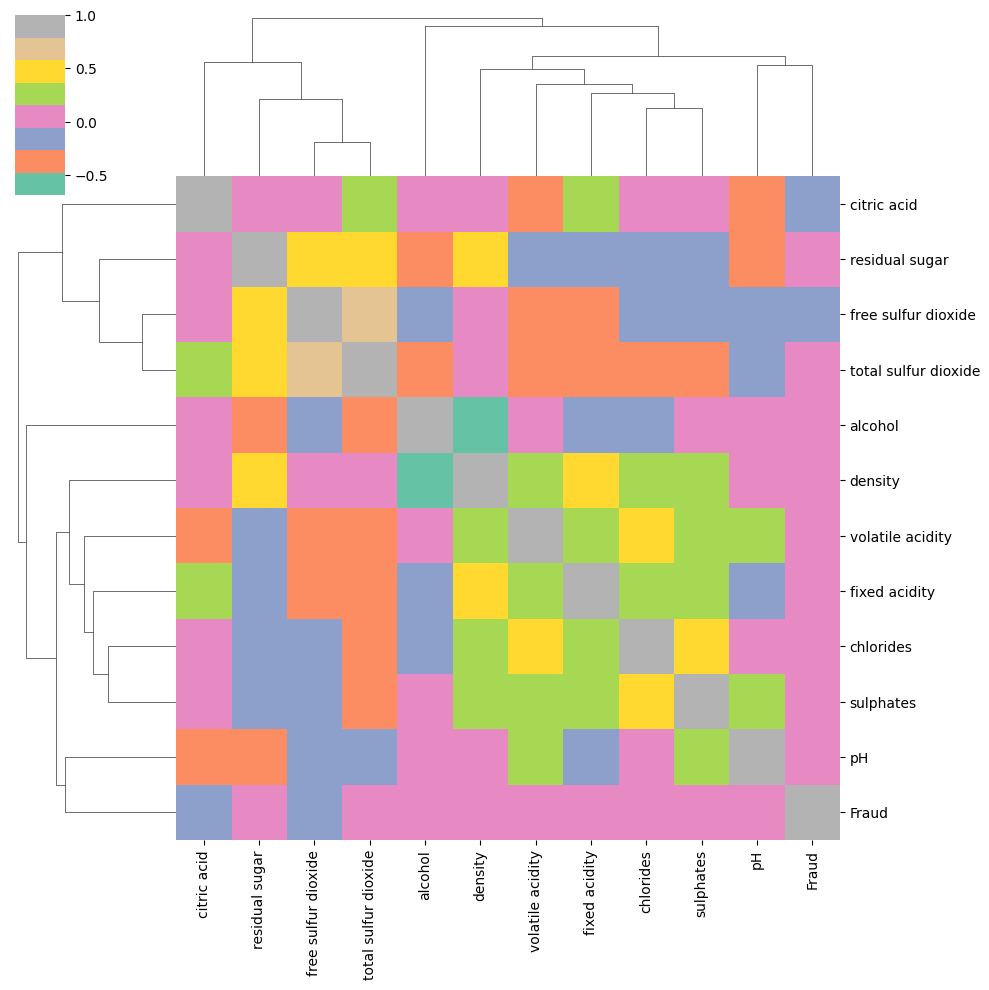

In [31]:
sns.clustermap(df.corr(numeric_only=True),cmap='Set2');

----
## Machine Learning Model

**TAAK: Converteer de categorische kolom "type" van een string van "red" of "white" naar dummy variabelen:**

**TAAK: Splits de data in X features en y target label ("quality" kolom)**

**TAAK: Voer een Train|Test split uit op de data, met 10% test size. Opmerking: de oplossing gebruikt een random state gelijk aan 101**

**TAAK: Schaal de X train en X test data.**

**TAAK: Maak een instantie van een Support Vector Machine-classifier. Voorheen hebben we dit model "leeg" gelaten (zonder parameters). We weten al dat de klassen ongebalanceerd zijn, en om dit probleem aan te pakken, kunnen we automatisch de gewichten omgekeerd proportioneel aanpassen aan de klassefrequenties in de invoergegevens met een argument call in de SVC() call. Bekijk de documentatie voor SVC online en zoek op wat het argument \ de parameter is.**

**TAAK: Gebruik een GridSearchCV om via grid search de beste waarde voor C en gamma te zoeken.**

**TAAK: Geef de confusion matrix en het classification report weer voor je model.**

**TAAK: Ten slotte, denk na over hoe goed dit model presteerde, zou je voorstellen om het te gebruiken? Zal dit realistisch gezien werken?**